# 02_1_MHCIIScore_Calculation
## Xiaonan Wang
## 16Sep2026

In [37]:
#%matplotlib nbagg
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from os import listdir
from os.path import isfile, join
import re
import anndata
# import scvi

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey', '#a1a1ce', 'purple', '#301934']) 
sc.settings.set_figure_params(dpi=80, color_map='viridis', vector_friendly=False,  dpi_save=300)

In [38]:
import sys

project_dir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1"

if project_dir not in sys.path:
    sys.path.append(project_dir)

import source

In [3]:
sc.logging.print_header()

Package,Version
numpy,2.4.5
matplotlib,3.10.9
scanpy,1.11.5
pandas,2.3.3
anndata,0.12.14
Component,Info
Python,"3.11.6 | packaged by conda-forge | (main, Oct 3 2023, 10:40:35) [GCC 12.3.0]"
OS,Linux-4.18.0-553.81.1.el8_10.x86_64-x86_64-with-glibc2.28
CPU,"5/64 logical CPU cores, x86_64"
GPU,No GPU found


In [39]:
datadir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/data/Spatial/"
outdir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/write_all/"

## Step0 - Read In Files

In [40]:
MA = sc.read_h5ad(outdir + 'MA.h5ad')

In [42]:
AM = MA[MA.obs['MA_group'] == 'AM'].copy()

In [43]:
AM

AnnData object with n_obs × n_vars = 17116 × 389
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'donor_id', 'core_id', 'tma_id', 'age', 'pmi', 'sex', 'tissue_annotation', 'tech', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'celltype_final', 'age_category', 'Leiden_MA', 'AM_score', 'IM_score', 'MA_group'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'features'
    uns: 'DE_Leiden_MA', 'Leiden_AM', 'Leiden_MA', 'Leiden_MA_colors', 'MA_group_colors', 'celltype_final_colors', 'donor_id_colors', 'leiden_0.2', 'leiden_0.3', 'leiden_0.3_colors', 'leiden_0.4', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_0.6', 'leiden_0.8', 'l

## Step1 - Map Mouse Genes To Human Orthologs

In [44]:
BD_DEgenes = pd.read_csv("/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/Inhouse_Data/XTY_BD_LungAM_mouse/Xiaotong_AM_mouse/BD_AM_MHCII/BD_DEgenes.csv")

BD_DEgenes = BD_DEgenes.drop(
    columns=["Unnamed: 0"],
    errors="ignore",
)

display(BD_DEgenes.head())
print(BD_DEgenes["group"].value_counts())

,group,names,scores,logfoldchanges,pvals,pvals_adj,AveExpr
0,ResAM2,H2-Ab1,9.926103,1.666673,3.205401e-23,2.176147e-19,1.949218
1,ResAM2,Cd74,9.785473,1.662541,1.299866e-22,5.883192e-19,2.668608
2,ResAM2,H2-Aa,9.253136,1.629088,2.180024e-20,7.400091e-17,1.940845
3,ResAM2,H2-Eb1,8.681267,1.634252,3.913860e-18,7.591769e-15,1.301339
4,ResAM2,Cxcl2,8.646409,1.082070,5.314517e-18,9.020064e-15,3.354383


group
ResAM2        13578
ResAM1        13578
Cycling AM    13578
Name: count, dtype: int64


In [45]:
ortholog_path = (
    "/dssg/home/acct-svetoslav_chakarov/"
    "svetoslav_chakarov/Files/human_mouse_orthologs.csv"
)

human_mouse_orthologs  = pd.read_csv(ortholog_path)

print(human_mouse_orthologs.shape)
display(human_mouse_orthologs.head())

(17177, 3)


,external_gene_name,mmusculus_homolog_associated_gene_name,mmusculus_homolog_orthology_type
0,MT-ND1,mt-Nd1,ortholog_one2one
1,MT-ND2,mt-Nd2,ortholog_one2one
2,MT-CO1,mt-Co1,ortholog_one2one
3,MT-CO2,mt-Co2,ortholog_one2one
4,MT-ATP8,mt-Atp8,ortholog_one2one


In [46]:
BD_DEgenes = source.add_human_gene_name(
    de_table=BD_DEgenes,
    ortholog_table=human_mouse_orthologs,
    mouse_gene_col="names",
    output_col="Human_gene_name",
)

In [47]:
BD_DEgenes.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,AveExpr,Human_gene_name,Human_gene_mapping_method
0,ResAM2,H2-Ab1,9.926103,1.666673,3.205401e-23,2.176147e-19,1.949218,HLA-DQB2,orthologue_table
1,ResAM2,Cd74,9.785473,1.662541,1.299866e-22,5.883192e-19,2.668608,CD74,orthologue_table
2,ResAM2,H2-Aa,9.253136,1.629088,2.180024e-20,7.400091e-17,1.940845,H2-AA,uppercase_fallback
3,ResAM2,H2-Eb1,8.681267,1.634252,3.913860e-18,7.591769e-15,1.301339,H2-EB1,uppercase_fallback
4,ResAM2,Cxcl2,8.646409,1.082070,5.314517e-18,9.020064e-15,3.354383,CXCL2,uppercase_fallback


## Step2 - MHCIIHi score - All Sig

In [48]:
MHCIIhi_sig = BD_DEgenes.loc[
    (BD_DEgenes["group"] == "ResAM2")
    & (BD_DEgenes["Human_gene_name"].isin(AM.var_names))
    & (BD_DEgenes["pvals_adj"] < 0.1)
    & (BD_DEgenes["logfoldchanges"] > 0.25),
    :
]
display(MHCIIhi_sig)

,group,names,scores,logfoldchanges,pvals,pvals_adj,AveExpr,Human_gene_name,Human_gene_mapping_method
1,ResAM2,Cd74,9.785473,1.662541,1.299866e-22,5.883192e-19,2.668608,CD74,orthologue_table
4,ResAM2,Cxcl2,8.646409,1.082070,5.314517e-18,9.020064e-15,3.354383,CXCL2,uppercase_fallback
9,ResAM2,Tnf,6.536158,1.110630,6.311934e-11,4.417152e-08,1.508968,TNF,orthologue_table
12,ResAM2,Il1b,6.054169,1.057979,1.411440e-09,7.665815e-07,1.220553,IL1B,orthologue_table
20,ResAM2,Cd14,5.536523,0.554419,3.085359e-08,1.047325e-05,1.846713,CD14,orthologue_table
23,ResAM2,Pim1,5.145216,0.351752,2.672132e-07,6.845701e-05,2.374640,PIM1,orthologue_table
31,ResAM2,Fn1,4.545301,0.548671,5.485671e-06,9.195611e-04,1.592982,FN1,orthologue_table
41,ResAM2,Clec4e,3.609637,0.556312,3.066251e-04,2.449033e-02,0.777312,CLEC4E,orthologue_table
65,ResAM2,Car4,3.217930,0.430767,1.291192e-03,6.283803e-02,1.664436,CA4,orthologue_table
68,ResAM2,Epcam,3.107082,0.389699,1.889438e-03,7.821584e-02,0.971205,EPCAM,orthologue_table


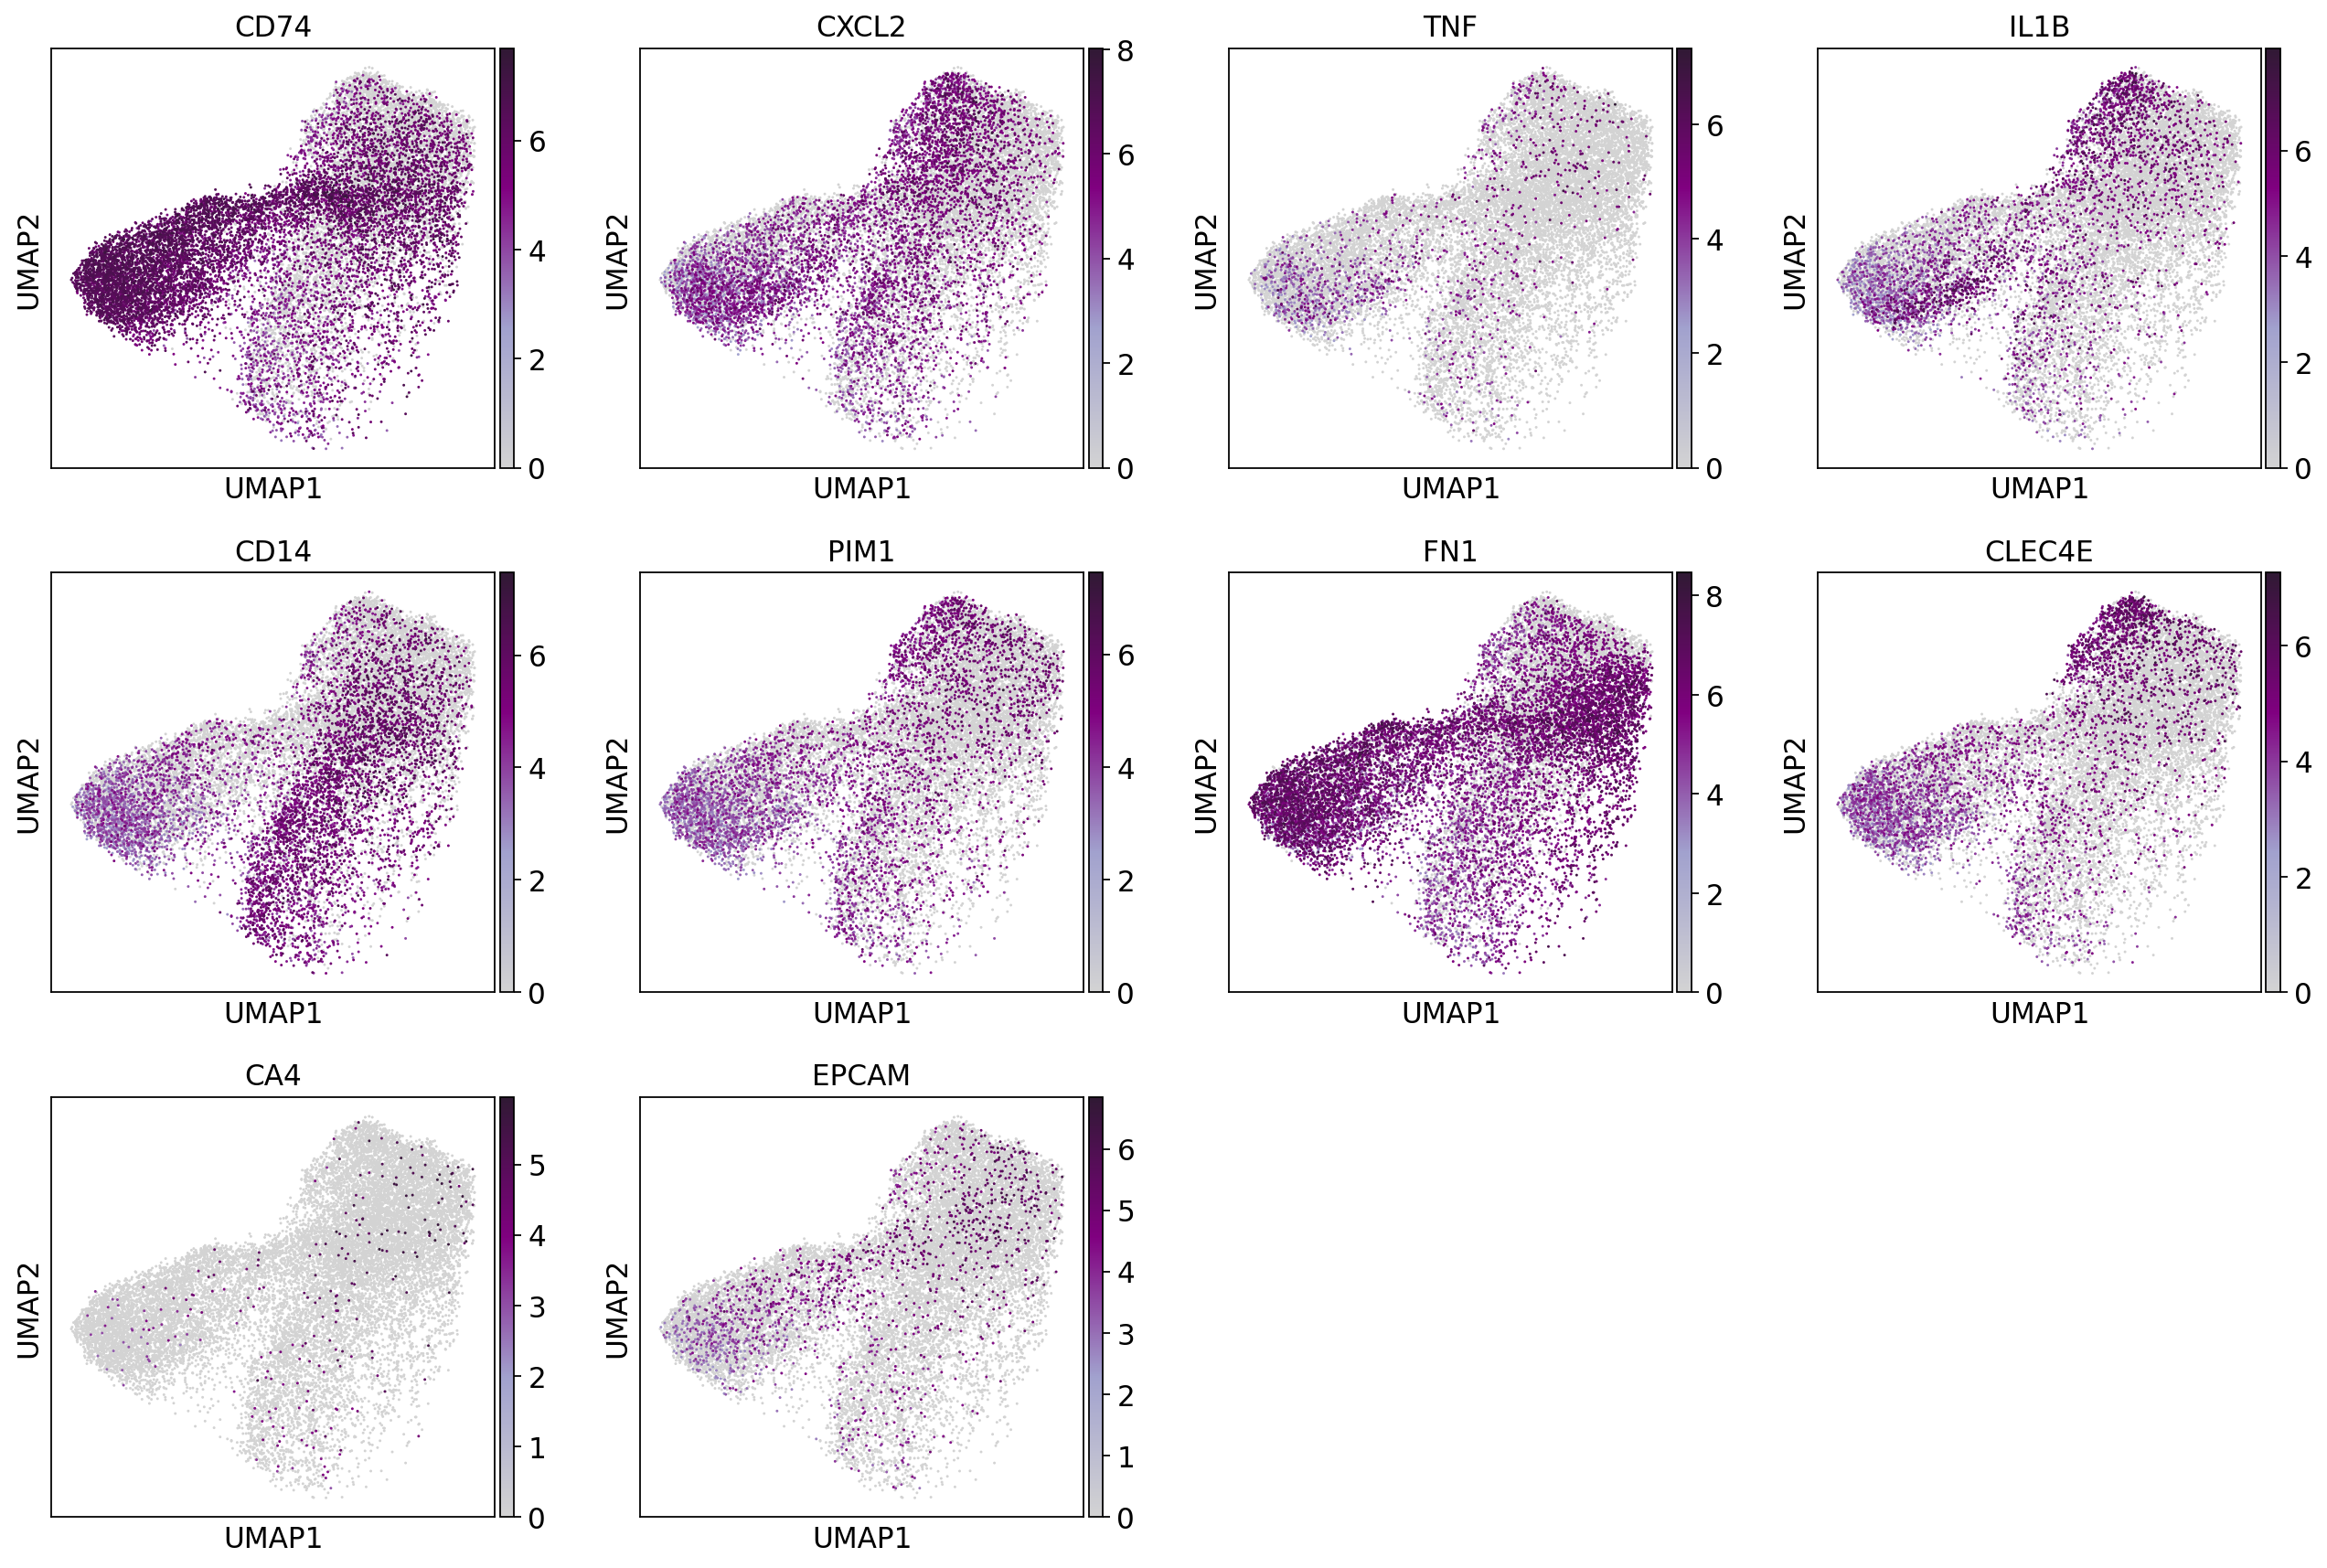

In [50]:
sc.pl.umap(AM, color=MHCIIhi_sig['Human_gene_name'], color_map=cmap, use_raw=False)

In [51]:
MHCIIlo_sig = BD_DEgenes.loc[
    (BD_DEgenes["group"] == "ResAM1")
    & (BD_DEgenes["Human_gene_name"].isin(AM.var_names))
    & (BD_DEgenes["pvals_adj"] < 0.1)
    & (BD_DEgenes["logfoldchanges"] > 0.25),
    :
]
display(MHCIIlo_sig)

,group,names,scores,logfoldchanges,pvals,pvals_adj,AveExpr,Human_gene_name,Human_gene_mapping_method
13599,ResAM1,Mpeg1,5.926810,0.362144,3.088760e-09,0.000001,2.763449,MPEG1,uppercase_fallback
13622,ResAM1,Cd68,4.917208,0.262873,8.778718e-07,0.000185,2.702076,CD68,uppercase_fallback
13658,ResAM1,Ctsl,4.133498,0.461687,3.572838e-05,0.004710,1.018265,CTSL,uppercase_fallback
13722,ResAM1,Cd2,3.514109,0.313251,4.412312e-04,0.033284,1.641476,CD2,orthologue_table
13777,ResAM1,Nceh1,3.223228,0.262966,1.267546e-03,0.070248,1.918487,NCEH1,orthologue_table


For MHCII lo, logFCs are too low to be true.

In [52]:
MHCIIhi_genes = MHCIIhi_sig['names'].values

In [53]:
MHCIIhi_genes

array(['Cd74', 'Cxcl2', 'Tnf', 'Il1b', 'Cd14', 'Pim1', 'Fn1', 'Clec4e',
       'Car4', 'Epcam'], dtype=object)

In [54]:
AM = source.assign_mhcii_single_signature(
    adata=AM,
    signature_genes=MHCIIhi_genes,
    core_genes=(),
    score_name="MHCIIhi_score",
    output_col="MHCII_group",
    score_cutoff=0,
    require_core_detection=False,
    use_raw=True,
    scale=True,
    min_signature_genes=3,
)

In [56]:
palette = {
    "MHCIIhi": "#E7B2B6",
    "MHCIIlo": "#B7C3E0",
}

In [57]:
AM.uns['MHCII_group_colors'] = [palette[x] for x in AM.obs['MHCII_group'].cat.categories]

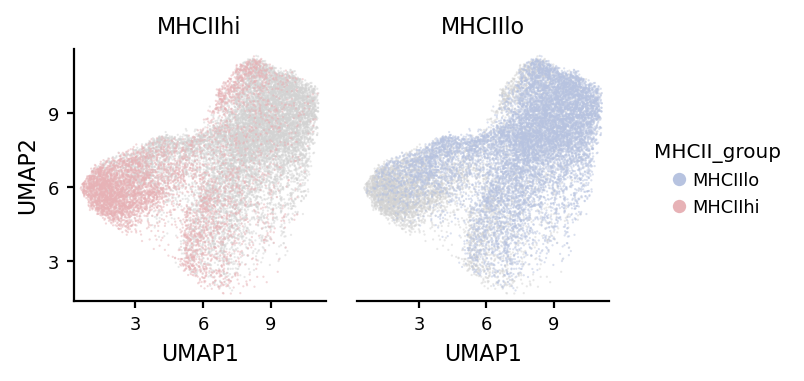

In [73]:
fig, axes = plot_anndata_group_umap(
    AM,
    group_col="MHCII_group",
    split_by="MHCII_group",
    split_categories=[
        "MHCIIhi",
        "MHCIIlo"
    ],
    point_size=1,
    point_alpha=0.5,
    width_cm=4,
    height_cm=4,
    top_cm=0.9,
    shared_limits=True,
    rasterized=True,
    legend_ncol=1,
    legend_width_cm=4.0
)

In [59]:
plt.rcParams["axes.grid"] = False

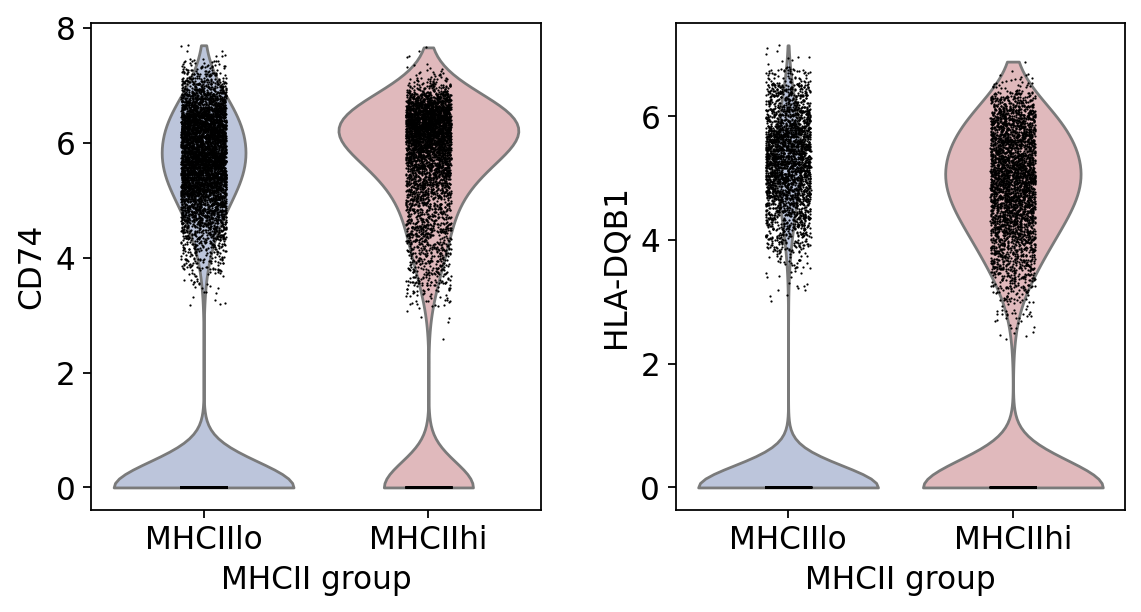

In [60]:
sc.pl.violin(
    AM,
    keys=["CD74", "HLA-DQB1"],
    groupby="MHCII_group",
    order=["MHCIIlo", "MHCIIhi"],
    stripplot=True,
    multi_panel=True,
    use_raw=False,
)

In [61]:
mhcii_detection = source.gene_detection_by_group(
    AM,
    genes=["CD74", "HLA-DQB1"],
    groupby="MHCII_group",
)

display(mhcii_detection)

,group,pct_expressing,gene
0,MHCIIhi,78.464076,CD74
1,MHCIIhi,62.719941,HLA-DQB1
2,MHCIIlo,48.267581,CD74
3,MHCIIlo,24.536878,HLA-DQB1


In [62]:
AM.obs['MHCII_group'].value_counts()

MHCII_group
MHCIIlo    11660
MHCIIhi     5456
Name: count, dtype: int64

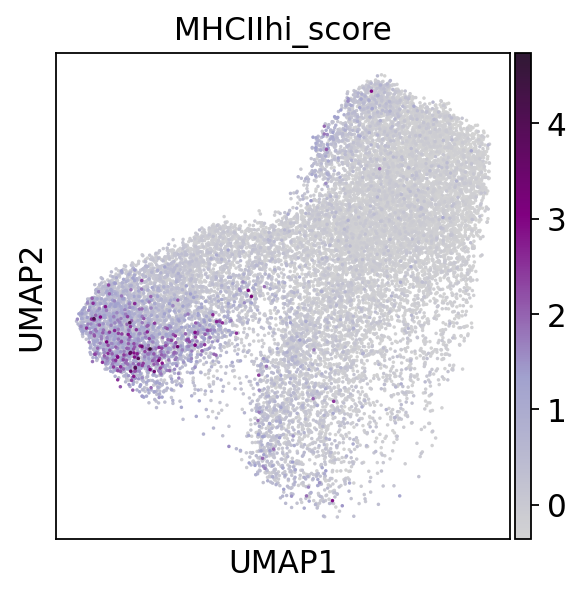

In [63]:
sc.pl.umap(
    AM,
    color=[
        "MHCIIhi_score",
    ],
    s=10,
    color_map=cmap
)

## Step3 - MHCIIHi score - HC Sig

In [64]:
MHCIIhi_HC = BD_DEgenes.loc[
    (BD_DEgenes["group"] == "ResAM2")
    & (BD_DEgenes["Human_gene_name"].isin(AM.var_names))
    & (BD_DEgenes["pvals_adj"] < 0.1)
    & (BD_DEgenes["logfoldchanges"] > 1),
    :
]
display(MHCIIhi_HC)

,group,names,scores,logfoldchanges,pvals,pvals_adj,AveExpr,Human_gene_name,Human_gene_mapping_method
1,ResAM2,Cd74,9.785473,1.662541,1.299866e-22,5.883192e-19,2.668608,CD74,orthologue_table
4,ResAM2,Cxcl2,8.646409,1.082070,5.314517e-18,9.020064e-15,3.354383,CXCL2,uppercase_fallback
9,ResAM2,Tnf,6.536158,1.110630,6.311934e-11,4.417152e-08,1.508968,TNF,orthologue_table
12,ResAM2,Il1b,6.054169,1.057979,1.411440e-09,7.665815e-07,1.220553,IL1B,orthologue_table


In [65]:
MHCIIhi_HC_genes = MHCIIhi_HC['names'].values

In [66]:
AM = source.assign_mhcii_single_signature(
    adata=AM,
    signature_genes=MHCIIhi_HC_genes,
    core_genes=(),
    score_name="MHCIIhi_score_HC",
    output_col="MHCII_group_HC",
    score_cutoff=0,
    require_core_detection=False,
    use_raw=True,
    scale=True,
    min_signature_genes=3,
)

In [67]:
AM.uns['MHCII_group_HC_colors'] = [palette[x] for x in AM.obs['MHCII_group_HC'].cat.categories]

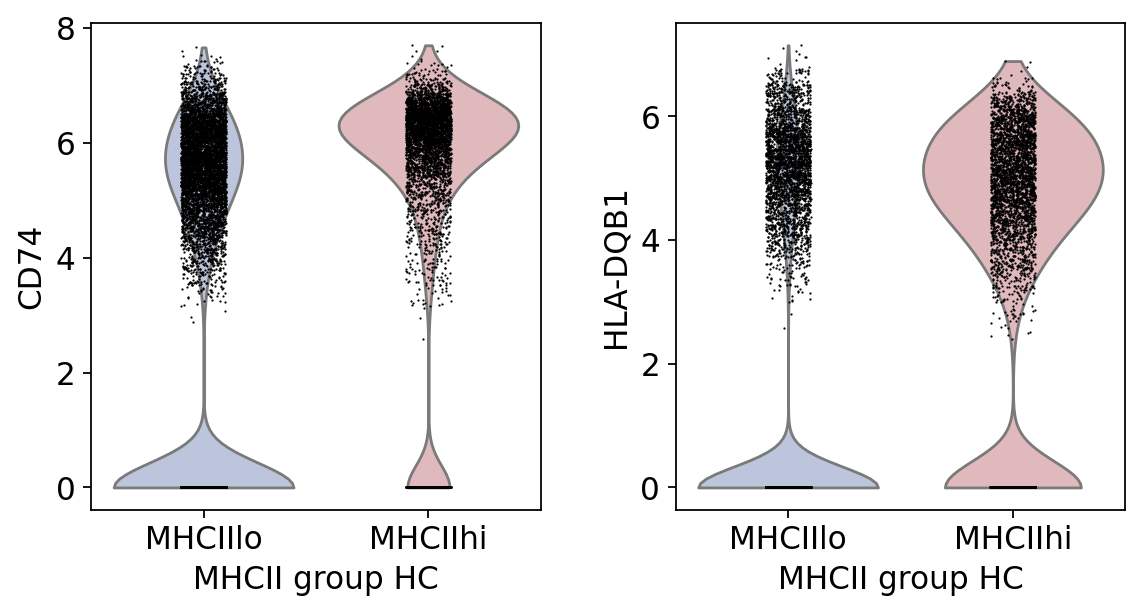

In [68]:
sc.pl.violin(
    AM,
    keys=["CD74", "HLA-DQB1"],
    groupby="MHCII_group_HC",
    order=["MHCIIlo", "MHCIIhi"],
    stripplot=True,
    multi_panel=True,
    use_raw=False,
)

In [69]:
mhcii_detection = source.gene_detection_by_group(
    AM,
    genes=["CD74", "HLA-DQB1"],
    groupby="MHCII_group_HC",
)

display(mhcii_detection)

,group,pct_expressing,gene
0,MHCIIhi,88.135593,CD74
1,MHCIIhi,74.896931,HLA-DQB1
2,MHCIIlo,47.537255,CD74
3,MHCIIlo,23.631373,HLA-DQB1


In [70]:
AM.obs['MHCII_group_HC'].value_counts()

MHCII_group_HC
MHCIIlo    12750
MHCIIhi     4366
Name: count, dtype: int64

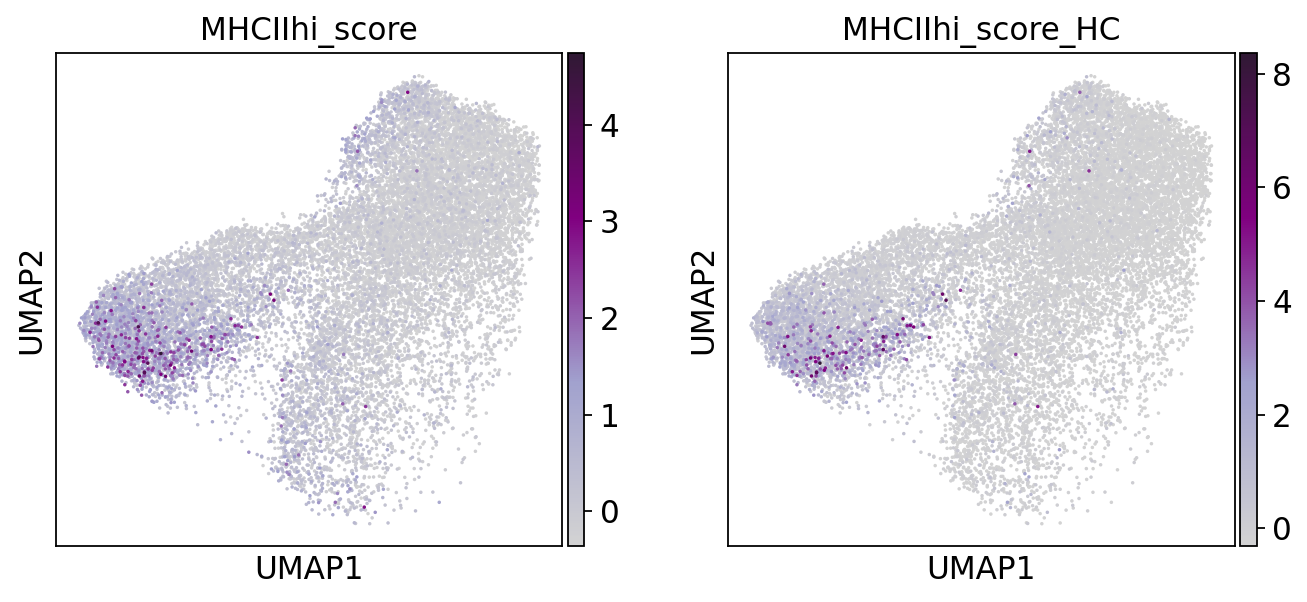

In [71]:
sc.pl.umap(
    AM,
    color=[
        "MHCIIhi_score", "MHCIIhi_score_HC"
    ],
    s=10,
    color_map=cmap
)

In [72]:
AM.write(outdir + 'AM_updated.h5ad')

In [5]:
AM = sc.read_h5ad(outdir + 'AM_updated.h5ad')